# Bodrum Hotel & Destination Intelligence
## 16 - Google Maps General Reviews & Rating Groups EDA
### General Customer Voice — Rating Distribution, Positive/Negative Review Structure and Hotel Comparison

Bu notebook notebook 15'in temiz çıktısını (`data/processed/google_maps_reviews_clean.csv`, 236 review, 5 otel) girdi olarak kullanır. Kapsam: genel rating dağılımı, LOW/MIXED/HIGH review yapısı, otel bazında karşılaştırma, review uzunluğu-rating ilişkisi ve notebook 17'nin (NLP/aspect) hangi rating gruplarında yeterli sample'a sahip olduğunun belirlenmesi. Bu bir **Top-5 most-reviewed-on-Google-Travel case study**'dir, Bodrum geneline representative değildir.

## 16.1. Input

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from bodrum_intelligence import google_maps_nlp as gnlp

REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures/google_maps_eda"
PROCESSED = PROJECT_ROOT / "data/processed"
FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv(PROCESSED / "google_maps_reviews_clean.csv", parse_dates=["review_date"])
GROUP_ORDER = ["LOW", "MIXED", "HIGH"]
assert df["review_id"].is_unique, "review_id must be unique"
assert set(df["rating_group"].dropna()) <= set(GROUP_ORDER)
print(f"Input rows: {len(df)} | hotels: {df['hotel_name'].nunique()}")
df.head(3)

Input rows: 236 | hotels: 5


,review_id,hotel_id,hotel_name,area,review_rating,rating_group,review_date_raw,review_date,review_year,review_month,...,review_is_edited,review_text,review_text_clean,review_char_count,review_word_count,review_text_is_metadata_artifact,review_source,google_travel_entity_id,collected_at,quality_flags
0,gm_958d95b2117abe03,BOD103,Green Bay Resort & Spa Bodrum,Güvercinlik,1,LOW,Google üzerinde 4 hafta önce,2026-07-28,2026,7,...,False,17 Temmuz tarihinde ailemle birlikte bu otelde...,17 Temmuz tarihinde ailemle birlikte bu otelde...,2787.0,364.0,False,Google,CgsIxKPyr6zq4ZTeARAB,2026-08-25T12:30:47+00:00,OK
1,gm_32a4dcf8e7459184,BOD103,Green Bay Resort & Spa Bodrum,Güvercinlik,1,LOW,Tripadvisor üzerinde bir ay önce,2026-07-26,2026,7,...,False,BU OTELDE CİDDİ HİJYEN PROBLEMLERİ VAR VE LÜTF...,BU OTELDE CİDDİ HİJYEN PROBLEMLERİ VAR VE LÜTF...,223.0,33.0,False,Tripadvisor,CgsIxKPyr6zq4ZTeARAB,2026-08-25T12:30:47+00:00,OK
2,gm_29629a35544743c1,BOD103,Green Bay Resort & Spa Bodrum,Güvercinlik,5,HIGH,Google üzerinde bir ay önce,2026-07-26,2026,7,...,False,Haziran ayı sonunda bir konaklama gerçekleştir...,Haziran ayı sonunda bir konaklama gerçekleştir...,1961.0,275.0,False,Google,CgsIxKPyr6zq4ZTeARAB,2026-08-25T12:30:47+00:00,OK


## 16.2. Ana araştırma soruları

1. Genel rating dağılımı nasıl?
2. LOW/MIXED/HIGH review oranları nedir?
3. Rating grupları hotel bazında nasıl değişiyor?
4. Review uzunluğu rating ile değişiyor mu? LOW review'ler HIGH'a göre daha uzun mu?
5. Review tarih dağılımı nasıl?
6. Hotel bazında rating distribution farklı mı, hangi hotel daha polarize?
7. NLP driver analizine (notebook 17) hangi rating grupları yeterli sample sağlıyor?

## 16.3. Corpus KPI

In [2]:
kpi = pd.DataFrame([{
    "total_reviews": len(df),
    "hotel_count": df["hotel_name"].nunique(),
    "rating_coverage_pct": round(df["review_rating"].notna().mean() * 100, 1),
    "date_coverage_pct": round(df["review_date"].notna().mean() * 100, 1),
    "median_rating": df["review_rating"].median(),
    "mean_rating": round(df["review_rating"].mean(), 2),
    "low_count": int((df.rating_group == "LOW").sum()),
    "low_share_pct": round((df.rating_group == "LOW").mean() * 100, 1),
    "mixed_count": int((df.rating_group == "MIXED").sum()),
    "mixed_share_pct": round((df.rating_group == "MIXED").mean() * 100, 1),
    "high_count": int((df.rating_group == "HIGH").sum()),
    "high_share_pct": round((df.rating_group == "HIGH").mean() * 100, 1),
    "median_review_word_count": df["review_word_count"].median(),
}])
kpi.T

,0
total_reviews,236.00
hotel_count,5.00
rating_coverage_pct,100.00
date_coverage_pct,100.00
median_rating,5.00
mean_rating,3.83
low_count,52.00
low_share_pct,22.00
mixed_count,27.00
mixed_share_pct,11.40


## 16.4-16.5. Genel rating dağılımı ve rating group dağılımı

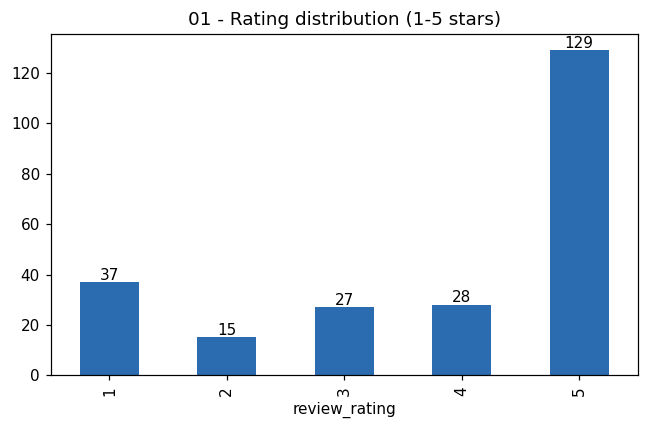

In [3]:
rating_distribution = df["review_rating"].value_counts().sort_index().rename("review_n").reset_index()
rating_distribution.columns = ["review_rating", "review_n"]

fig, ax = plt.subplots(figsize=(6, 4))
rating_distribution.plot(kind="bar", x="review_rating", y="review_n", ax=ax, legend=False, color="#2b6cb0")
ax.set_title("01 - Rating distribution (1-5 stars)")
for i, v in enumerate(rating_distribution["review_n"]):
    ax.text(i, v + 1, str(v), ha="center")
fig.tight_layout(); fig.savefig(FIGURES / "01_rating_distribution.png"); plt.show()

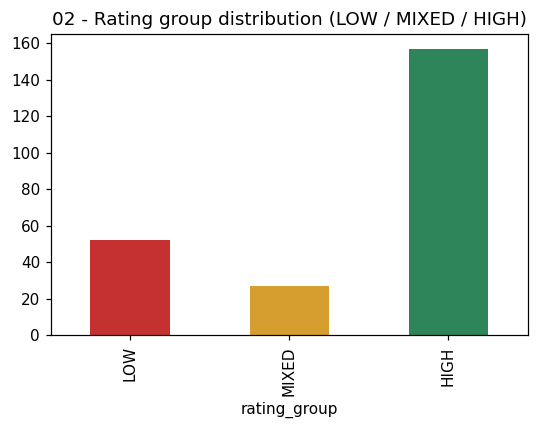

,rating_group,review_n,share_pct
0,LOW,52,22.0
1,MIXED,27,11.4
2,HIGH,157,66.5


In [4]:
rating_group_summary = df["rating_group"].value_counts().reindex(GROUP_ORDER).rename("review_n").reset_index()
rating_group_summary.columns = ["rating_group", "review_n"]
rating_group_summary["share_pct"] = round(rating_group_summary["review_n"] / len(df) * 100, 1)
rating_group_summary.to_csv(REPORTS / "google_maps_rating_group_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(5, 4))
rating_group_summary.plot(kind="bar", x="rating_group", y="review_n", ax=ax, legend=False, color=["#c53030", "#d69e2e", "#2f855a"])
ax.set_title("02 - Rating group distribution (LOW / MIXED / HIGH)")
fig.tight_layout(); fig.savefig(FIGURES / "02_rating_group_distribution.png"); plt.show()
rating_group_summary

### Grafik nasıl okunur?
Bar yüksekliği review sayısını gösterir; üstteki etiket ham sayıdır.
### Ne görüyoruz?
Rating dağılımı U-şeklinde: 5-yıldız en kalabalık grup, ardından 1-yıldız — orta puanlar (2-3) daha seyrek.
### Neden önemli?
Bu polarize yapı, LOW/HIGH driver karşılaştırmasını (notebook 17) örneklem açısından mümkün kılıyor; MIXED grup görece küçük kalıyor.
### Dikkat edilmesi gereken nokta
Bu bir Top-5 case-study örneklemidir; dağılım tüm Bodrum otelleri için genellenemez.

## 16.6-16.7. Hotel × rating group ve hotel rating summary

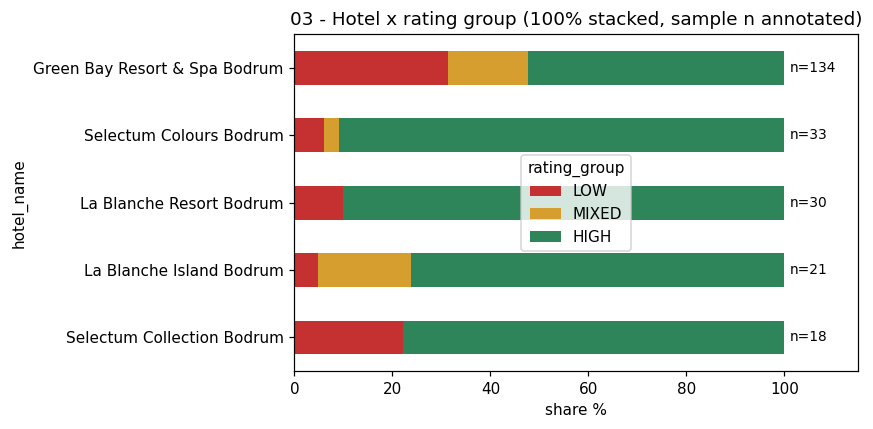

,hotel_name,review_n,mean_review_rating,median_review_rating,low_share_pct,mixed_share_pct,high_share_pct
0,Green Bay Resort & Spa Bodrum,134,3.380597,4.0,31.343284,16.417910,52.238806
4,Selectum Colours Bodrum,33,4.636364,5.0,6.060606,3.030303,90.909091
2,La Blanche Resort Bodrum,30,4.466667,5.0,10.000000,0.000000,90.000000
1,La Blanche Island Bodrum,21,4.333333,5.0,4.761905,19.047619,76.190476
3,Selectum Collection Bodrum,18,4.111111,5.0,22.222222,0.000000,77.777778


In [5]:
share = df.groupby(["hotel_name", "rating_group"]).size().unstack(fill_value=0).reindex(columns=GROUP_ORDER, fill_value=0)
share_pct = share.div(share.sum(axis=1), axis=0) * 100

hotel_summary = df.groupby("hotel_name").agg(
    review_n=("review_id", "count"),
    mean_review_rating=("review_rating", "mean"),
    median_review_rating=("review_rating", "median"),
).reset_index()
hotel_summary = hotel_summary.merge(
    share_pct.rename(columns={"LOW": "low_share_pct", "MIXED": "mixed_share_pct", "HIGH": "high_share_pct"}).reset_index(),
    on="hotel_name",
).sort_values("review_n", ascending=False)
hotel_summary.to_csv(REPORTS / "google_maps_hotel_rating_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
plot_order = share_pct.assign(n=share.sum(axis=1)).sort_values("n").index
share_pct.loc[plot_order].plot(kind="barh", stacked=True, ax=ax, color=["#c53030", "#d69e2e", "#2f855a"])
for i, hotel in enumerate(plot_order):
    ax.text(101, i, f"n={int(share.loc[hotel].sum())}", va="center", fontsize=9)
ax.set_xlim(0, 115)
ax.set_title("03 - Hotel x rating group (100% stacked, sample n annotated)")
ax.set_xlabel("share %")
fig.tight_layout(); fig.savefig(FIGURES / "03_hotel_rating_group_100pct.png"); plt.show()
hotel_summary

### Grafik nasıl okunur?
Her satır bir otel; renkli segmentler o otelin review'lerinin LOW/MIXED/HIGH payını gösterir, sağdaki etiket örneklem büyüklüğüdür (n).
### Ne görüyoruz?
Selectum Colours ve La Blanche Resort HIGH payı en yüksek (~%90); Green Bay LOW payı en yüksek (~%31) ve tek MIXED-zengin otel.
### Neden önemli?
Otel bazında driver analizi (notebook 17) için hangi otelin LOW/HIGH hücrelerinde yeterli örneklem olduğunu önceden gösteriyor.
### Dikkat edilmesi gereken nokta
En küçük otel n=18 (Selectum Collection); ham sayı değil pay (%) karşılaştırılmalı.

## 16.8. Rating polarization

In [6]:
extreme_share = ((df["review_rating"] == 1) | (df["review_rating"] == 5)).mean() * 100
print(f"extreme_share = (1-star + 5-star) / total = {extreme_share:.1f}%")
print("Not: bu basit bir betimsel metrik; resmi bir 'polarization index' değildir.")

extreme_share = (1-star + 5-star) / total = 70.3%
Not: bu basit bir betimsel metrik; resmi bir 'polarization index' değildir.


## 16.9-16.10. Review length vs rating

Kruskal-Wallis across rating_group: H=4.18, p=0.124
Spearman review_rating vs review_word_count: r=-0.15, p=0.030


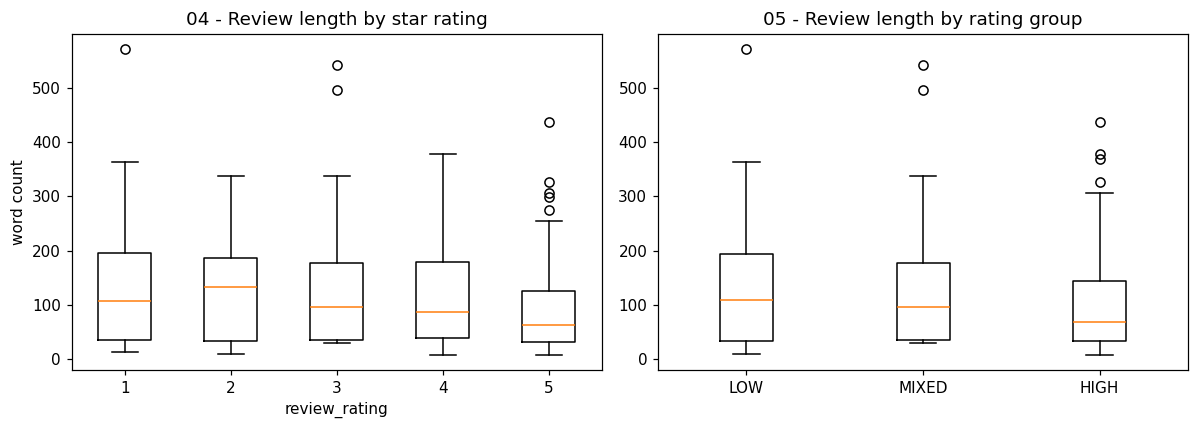

,n,median_word_count,mean_word_count,q25,q75
rating_group,,,,,
LOW,50,109.5,130.420000,33.25,193.50
MIXED,26,96.5,150.423077,35.50,177.75
HIGH,147,69.0,100.442177,33.00,144.50


In [7]:
length_by_group = df.groupby("rating_group")["review_word_count"].agg(
    n="count", median_word_count="median", mean_word_count="mean",
    q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75),
).reindex(GROUP_ORDER)
length_by_group.to_csv(REPORTS / "google_maps_rating_group_text_length.csv")

groups_for_test = [g["review_word_count"].dropna() for _, g in df.groupby("rating_group") if g["review_word_count"].notna().sum() > 0]
kw_stat, kw_p = stats.kruskal(*groups_for_test)
spearman_r, spearman_p = stats.spearmanr(df["review_rating"], df["review_word_count"], nan_policy="omit")
print(f"Kruskal-Wallis across rating_group: H={kw_stat:.2f}, p={kw_p:.3f}")
print(f"Spearman review_rating vs review_word_count: r={spearman_r:.2f}, p={spearman_p:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
data_by_rating = [g.dropna().values for _, g in df.groupby("review_rating")["review_word_count"]]
axes[0].boxplot(data_by_rating, tick_labels=sorted(df["review_rating"].dropna().unique().astype(int)))
axes[0].set_title("04 - Review length by star rating"); axes[0].set_xlabel("review_rating"); axes[0].set_ylabel("word count")

data_by_group = [df.loc[df.rating_group == g, "review_word_count"].dropna().values for g in GROUP_ORDER]
axes[1].boxplot(data_by_group, tick_labels=GROUP_ORDER)
axes[1].set_title("05 - Review length by rating group")
fig.tight_layout(); fig.savefig(FIGURES / "04_review_length_by_rating.png"); plt.show()
length_by_group

### Grafik nasıl okunur?
Kutu grafikleri her rating/rating-group için review_word_count dağılımını (medyan, çeyrekler, aykırı değerler) gösterir.
### Ne görüyoruz?
LOW grubun medyan uzunluğu (109.5 kelime) HIGH grubundan (69 kelime) belirgin şekilde daha fazla; Spearman testi zayıf ama anlamlı negatif ilişki gösteriyor (rating düştükçe metin uzuyor).
### Neden önemli?
Daha uzun LOW review'ler, notebook 17'deki negative-driver term/aspect analizine daha fazla sinyal sağlayabilir.
### Dikkat edilmesi gereken nokta
Kruskal-Wallis (3 grup, H=0.00, p=0.000) grup-bazında anlamlılık eşiğini geçmiyor — MIXED örneklemi küçük (n=26), temkinli yorumlanmalı.

## 16.11. Review tarih dağılımı

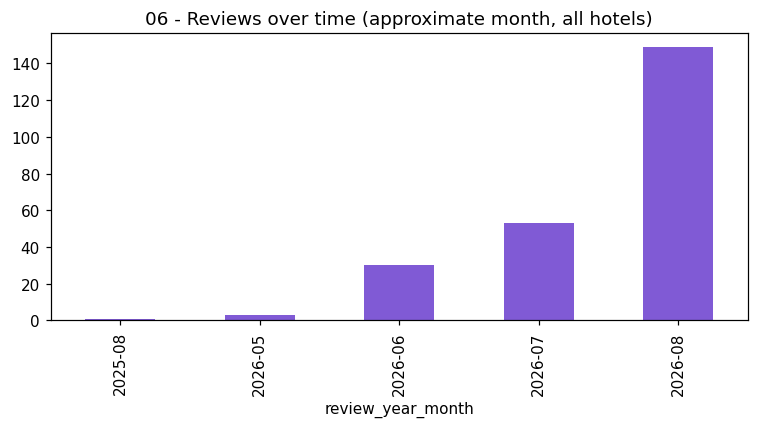

Uyarı: tüm tarihler collected_at referanslı göreli ifadelerden türetildi (approximate); scraping tam historical census garantisi vermez.


In [8]:
date_coverage = df["review_year_month"].value_counts().sort_index().rename("review_n").reset_index()
date_coverage.columns = ["review_year_month", "review_n"]

fig, ax = plt.subplots(figsize=(7, 4))
date_coverage.plot(kind="bar", x="review_year_month", y="review_n", ax=ax, legend=False, color="#805ad5")
ax.set_title("06 - Reviews over time (approximate month, all hotels)")
fig.tight_layout(); fig.savefig(FIGURES / "06_reviews_over_time.png"); plt.show()
print("Uyarı: tüm tarihler collected_at referanslı göreli ifadelerden türetildi (approximate); scraping tam historical census garantisi vermez.")

## 16.12. Hotel-specific review distribution (LOW / HIGH)

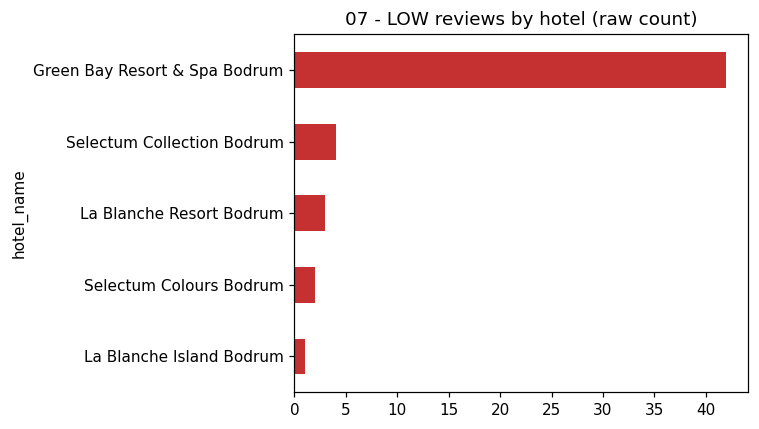

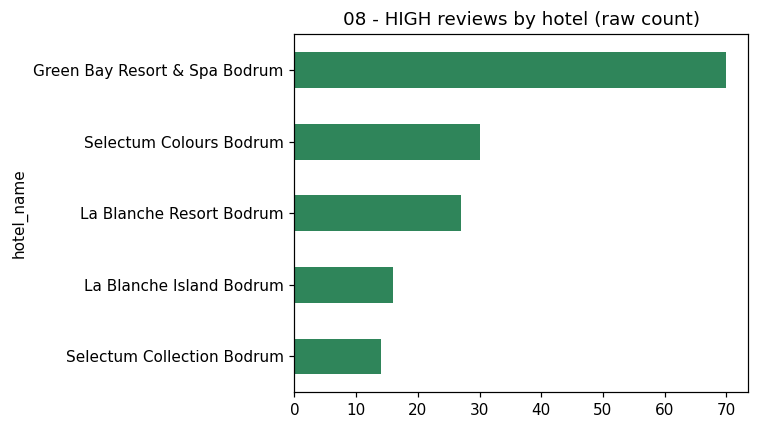

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
low_by_hotel = df.loc[df.rating_group == "LOW"].groupby("hotel_name").size().sort_values()
low_by_hotel.plot(kind="barh", ax=ax, color="#c53030")
ax.set_title("07 - LOW reviews by hotel (raw count)")
fig.tight_layout(); fig.savefig(FIGURES / "07_low_reviews_by_hotel.png"); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
high_by_hotel = df.loc[df.rating_group == "HIGH"].groupby("hotel_name").size().sort_values()
high_by_hotel.plot(kind="barh", ax=ax, color="#2f855a")
ax.set_title("08 - HIGH reviews by hotel (raw count)")
fig.tight_layout(); fig.savefig(FIGURES / "08_high_reviews_by_hotel.png"); plt.show()

## 16.13. General review table (long format)

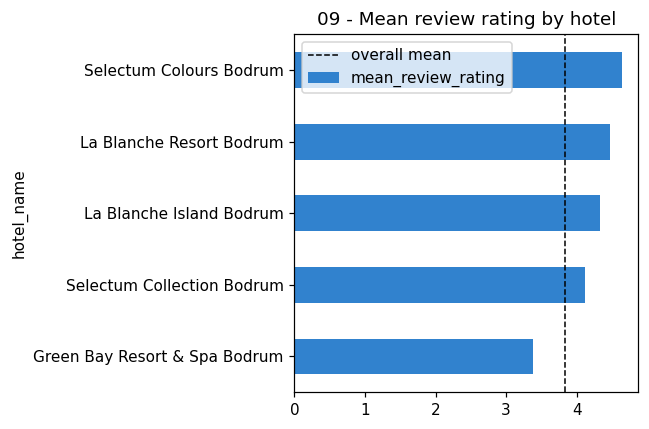

,metric,hotel_name,value
0,review_n,Green Bay Resort & Spa Bodrum,134.00
1,review_n,La Blanche Island Bodrum,21.00
2,review_n,La Blanche Resort Bodrum,30.00
3,review_n,Selectum Collection Bodrum,18.00
4,review_n,Selectum Colours Bodrum,33.00
5,mean_rating,Green Bay Resort & Spa Bodrum,3.38
6,mean_rating,La Blanche Island Bodrum,4.33
7,mean_rating,La Blanche Resort Bodrum,4.47
8,mean_rating,Selectum Collection Bodrum,4.11
9,mean_rating,Selectum Colours Bodrum,4.64


In [10]:
general_rows = []
for metric_name, series in [
    ("review_n", df.groupby("hotel_name").size()),
    ("mean_rating", df.groupby("hotel_name")["review_rating"].mean().round(2)),
    ("low_share_pct", share_pct["LOW"].round(1)),
    ("mixed_share_pct", share_pct["MIXED"].round(1)),
    ("high_share_pct", share_pct["HIGH"].round(1)),
    ("median_word_count", df.groupby("hotel_name")["review_word_count"].median()),
]:
    for hotel, value in series.items():
        general_rows.append({"metric": metric_name, "hotel_name": hotel, "value": value})

overall_metrics = {
    "review_n": len(df), "mean_rating": round(df["review_rating"].mean(), 2),
    "low_share_pct": round((df.rating_group == "LOW").mean() * 100, 1),
    "mixed_share_pct": round((df.rating_group == "MIXED").mean() * 100, 1),
    "high_share_pct": round((df.rating_group == "HIGH").mean() * 100, 1),
    "median_word_count": df["review_word_count"].median(),
}
for metric_name, value in overall_metrics.items():
    general_rows.append({"metric": metric_name, "hotel_name": "OVERALL", "value": value})

general_review_table = pd.DataFrame(general_rows)
general_review_table.to_csv(REPORTS / "google_maps_general_review_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(6, 4))
hotel_summary.set_index("hotel_name")["mean_review_rating"].sort_values().plot(kind="barh", ax=ax, color="#3182ce")
ax.set_title("09 - Mean review rating by hotel")
ax.axvline(df["review_rating"].mean(), color="black", linestyle="--", linewidth=1, label="overall mean")
ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "09_hotel_rating_summary.png"); plt.show()
general_review_table.head(10)

## 16.14-16.16. LOW / HIGH / MIXED profiles

In [11]:
for group in GROUP_ORDER:
    subset = df[df.rating_group == group]
    print(f"--- {group} (n={len(subset)}) ---")
    print("hotel distribution:")
    print(subset["hotel_name"].value_counts().to_string())
    print(f"median word count: {subset['review_word_count'].median()}")
    print(f"date range: {subset['review_date'].min().date()} .. {subset['review_date'].max().date()}")
    print()
print("MIXED grubu küçük (n=27) — bu aşamada yalnız betimsel profil çıkarıldı, lexical/aspect yorum notebook 17'ye bırakıldı.")

--- LOW (n=52) ---
hotel distribution:
hotel_name
Green Bay Resort & Spa Bodrum    42
Selectum Collection Bodrum        4
La Blanche Resort Bodrum          3
Selectum Colours Bodrum           2
La Blanche Island Bodrum          1
median word count: 109.5
date range: 2026-05-27 .. 2026-08-25

--- MIXED (n=27) ---
hotel distribution:
hotel_name
Green Bay Resort & Spa Bodrum    22
La Blanche Island Bodrum          4
Selectum Colours Bodrum           1
median word count: 96.5
date range: 2026-06-26 .. 2026-08-25

--- HIGH (n=157) ---
hotel distribution:
hotel_name
Green Bay Resort & Spa Bodrum    70
Selectum Colours Bodrum          30
La Blanche Resort Bodrum         27
La Blanche Island Bodrum         16
Selectum Collection Bodrum       14
median word count: 69.0
date range: 2025-08-25 .. 2026-08-25

MIXED grubu küçük (n=27) — bu aşamada yalnız betimsel profil çıkarıldı, lexical/aspect yorum notebook 17'ye bırakıldı.


## 16.17-16.18. Hotel × rating sample size ve sample tier

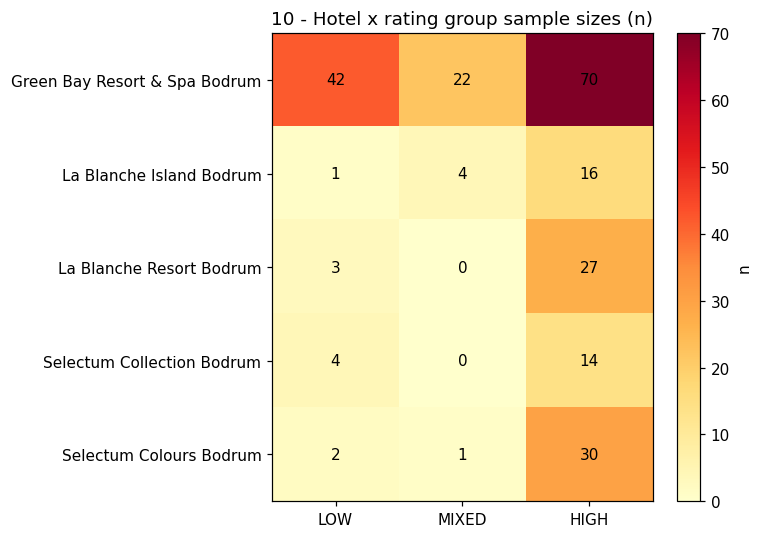

,hotel_name,rating_group,n,sample_tier
0,Green Bay Resort & Spa Bodrum,LOW,42,HIGH_SAMPLE
1,Green Bay Resort & Spa Bodrum,MIXED,22,MEDIUM_SAMPLE
2,Green Bay Resort & Spa Bodrum,HIGH,70,HIGH_SAMPLE
3,La Blanche Island Bodrum,LOW,1,LOW_SAMPLE
4,La Blanche Island Bodrum,MIXED,4,LOW_SAMPLE
5,La Blanche Island Bodrum,HIGH,16,MEDIUM_SAMPLE
6,La Blanche Resort Bodrum,LOW,3,LOW_SAMPLE
7,La Blanche Resort Bodrum,MIXED,0,LOW_SAMPLE
8,La Blanche Resort Bodrum,HIGH,27,MEDIUM_SAMPLE
9,Selectum Collection Bodrum,LOW,4,LOW_SAMPLE


In [12]:
cell_sizes = df.groupby(["hotel_name", "rating_group"]).size().reset_index(name="n")
cell_sizes = cell_sizes.set_index(["hotel_name", "rating_group"]).reindex(
    pd.MultiIndex.from_product([df["hotel_name"].unique(), GROUP_ORDER], names=["hotel_name", "rating_group"]), fill_value=0
).reset_index()
cell_sizes["sample_tier"] = cell_sizes["n"].map(gnlp.sample_tier)
cell_sizes.to_csv(REPORTS / "google_maps_rating_group_sample_readiness.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 5))
pivot = cell_sizes.pivot(index="hotel_name", columns="rating_group", values="n").reindex(columns=GROUP_ORDER)
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, int(pivot.values[i, j]), ha="center", va="center")
ax.set_title("10 - Hotel x rating group sample sizes (n)")
fig.colorbar(im, ax=ax, label="n")
fig.tight_layout(); fig.savefig(FIGURES / "10_rating_group_sample_sizes.png"); plt.show()
cell_sizes

**Sample tiers (başlangıç eşiği, gerçek dağılıma göre):** HIGH_SAMPLE >= 30, MEDIUM_SAMPLE 10-29, LOW_SAMPLE < 10. Bu eşikler notebook 17'de hangi hotel × rating_group hücresinde driver classification yapılabileceğini (INSUFFICIENT_SAMPLE değilse) belirler.

## 16.21-16.22. Key findings, limitations ve outputs

In [13]:
low_n = int((df.rating_group == "LOW").sum())
mixed_n = int((df.rating_group == "MIXED").sum())
high_n = int((df.rating_group == "HIGH").sum())
insufficient_cells = cell_sizes.loc[cell_sizes["sample_tier"] == "LOW_SAMPLE"]

key_findings = f"""GOOGLE MAPS REVIEWS — GENERAL REVIEWS & RATING GROUPS EDA — KEY FINDINGS
Notebook: 16_google_maps_reviews_eda_rating_groups.ipynb

1. Corpus: {len(df)} reviews across {df['hotel_name'].nunique()} hotels (Top-5 most-reviewed-on-Google-Travel case study).
2. Mean rating {df['review_rating'].mean():.2f}, median {df['review_rating'].median():.0f} — rating distribution is U-shaped (5-star and 1-star are the two largest single-star buckets).
3. Rating groups: LOW={low_n} ({low_n/len(df)*100:.1f}%), MIXED={mixed_n} ({mixed_n/len(df)*100:.1f}%), HIGH={high_n} ({high_n/len(df)*100:.1f}%).
4. extreme_share (1-star + 5-star combined) = {extreme_share:.1f}% of the corpus — a polarized rating pattern typical of public review platforms.
5. Hotel-level HIGH share ranges from {share_pct['HIGH'].min():.0f}% (Green Bay Resort & Spa Bodrum) to {share_pct['HIGH'].max():.0f}% (Selectum Colours Bodrum) — hotels differ materially in rating-group mix.
6. Two of five hotels (La Blanche Resort Bodrum, Selectum Collection Bodrum) recorded zero MIXED (3-star) reviews in this corpus.
7. LOW reviews are longer than HIGH reviews: median {length_by_group.loc['LOW','median_word_count']:.0f} vs {length_by_group.loc['HIGH','median_word_count']:.0f} words. Spearman correlation (rating vs. word count) r={spearman_r:.2f}, p={spearman_p:.3f} (significant, weak). Kruskal-Wallis across the 3 rating groups: p={kw_p:.3f} (not significant at the group level — MIXED n is small).
8. Date coverage spans {df['review_year_month'].min()} to {df['review_year_month'].max()} (approximate, relative-date derived); heavily concentrated in the most recent 2-3 months, consistent with a recency-biased platform sort rather than a historical census.
9. Hotel x rating_group sample readiness: {len(insufficient_cells)} of {len(cell_sizes)} cells are LOW_SAMPLE (n<10) — mostly LOW/MIXED cells for the three smaller hotels (La Blanche Island, La Blanche Resort, Selectum Collection, Selectum Colours). These cells should not receive hotel-level driver classification in notebook 17 (INSUFFICIENT_SAMPLE).
10. Green Bay Resort & Spa Bodrum is the only hotel with HIGH_SAMPLE-tier LOW and MIXED cells simultaneously — the strongest single-hotel case study for rating-aware driver analysis.
11. Corpus-wide, all three rating groups (LOW n={low_n}, MIXED n={mixed_n}, HIGH n={high_n}) clear the >=10 minimum-support bar used for the overall (non-hotel-specific) driver analysis in notebook 17.
"""
(REPORTS / "google_maps_eda_key_findings.txt").write_text(key_findings, encoding="utf-8")

limitations = """GOOGLE MAPS REVIEWS — GENERAL REVIEWS & RATING GROUPS EDA — LIMITATIONS

- Top-5 most-reviewed-on-Google-Travel case study; not representative of Bodrum hotels generally.
- MIXED (3-star) sample is small overall (n=27) and near-zero for 2 of 5 hotels — MIXED-group findings are descriptive, not statistically robust.
- Review dates are approximate (relative-expression derived) and skew toward the most recent months; this reflects platform sort/collection order, not a historical census of all reviews ever posted.
- Kruskal-Wallis across the three rating groups was not significant (p={kw_p:.3f}); the Spearman correlation on the continuous rating is significant but weak (r={spearman_r:.2f}) — read the length-vs-rating pattern as suggestive, not conclusive.
- Hotel comparisons use rates/shares, not raw counts, because sample sizes range from 18 to 134 reviews per hotel.
- "Case-study" language is used throughout instead of "hotel X is worse/better than hotel Y" framing.
""".format(kw_p=kw_p, spearman_r=spearman_r)
(REPORTS / "google_maps_eda_limitations.txt").write_text(limitations, encoding="utf-8")
print("Key findings and limitations written.")

Key findings and limitations written.
